In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1750784615.376130   20522 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750784615.380352   20522 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750784615.393599   20522 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750784615.393628   20522 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750784615.393630   20522 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750784615.393632   20522 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1750784617.577725   20522 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


# Chapter 12: Generative Deep Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

Generative AI and using deep learning architectures is particulary popular right now,
though I personally agree with the assessment that it "has fed a (not so) short-lived hype
wave worthy of the most torrid AI summer.  In any case, the promise of generative AI is that
it can be used as a tool to augment human capabilities, so more generative augmentive intelligence
rather than artifical general intelligence.

In this section we will look at some of the basic mechanisms and architectures for building generative
systems using deep learning networks.  We will look at generating text and images, and
what autoencoders and GAN networks are all about.

## 12.2 Deep Dream

DeepDream uses this same idea, with a few simple differences:

- With DeepDream, you try to maximize the activation of entire layers rather
  than that of a specific filter, thus mixing together visualizations of large numbers
  of features at once.
- You start not from blank, slightly noisy input, but rather from an existing
  image—thus the resulting effects latch on to preexisting visual patterns, distorting
  elements of the image in a somewhat artistic fashion.
- The input images are processed at different scales (called octaves), which
  improves the quality of the visualizations.

### 12.2.1 ImplementingDeepDream in Keras

Let’s start by retrieving a test image to dream with. We’ll use a view of the rugged
Northern California coast in the winter

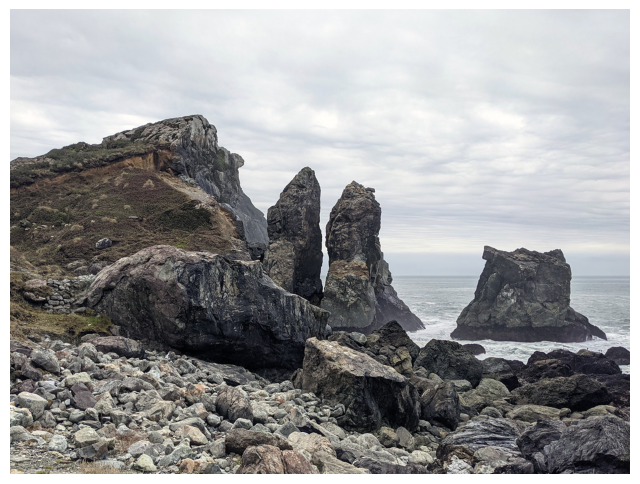

In [4]:
# fetching the test image
base_image_path = keras.utils.get_file("coast.jpg", origin="https://img-datasets.s3.amazonaws.com/coast.jpg")
plt.axis("off")
plt.imshow(keras.utils.load_img(base_image_path));

Next, we need a pretrained convnet.

Inception is known to produce nice-looking
DeepDreams, so we’ll use the Inception V3 model that comes with Keras.

In [5]:
from tensorflow.keras.applications import inception_v3
model = inception_v3.InceptionV3(weights="imagenet", include_top=False)

We'll use our pretrained convnet to create a feature extractor model that
returns the activations of the various intermediate layers.

For each layer, we pick a scalar score that weights the contribution of the layer
to the loss we will seek to maximize during the gradient ascent process.

In [6]:
model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,216 │ activation[0][0]  │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,432 │ activation_1[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      5,120 │ max_pooling2d[0]… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │    138,240 │ activation_3[0][… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, None,      │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [7]:
layer_settings = {
    "mixed4": 1.0,
    "mixed5": 1.5,
    "mixed6": 2.0,
    "mixed7": 2.5,
}

outputs_dict = dict(
    [
        (layer.name, layer.output)
        for layer in [model.get_layer(name)
            for name in layer_settings.keys()]
    ]
)

feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)

Next, we’ll compute the loss: the quantity we’ll seek to maximize during the gradientascent
process at each processing scale.

We’ll simultaneously maximize the activation of all filters in a number of layers. Specifically, we’ll maximize
a weighted mean of the L2 norm of the activations of a set of high-level layers.

We’ll start from a somewhat arbitrary configuration involving four layers—
but you’ll definitely want to explore many different configurations later.

In [8]:
# The DeepDream loss
def compute_loss(input_image):
    # extract activations
    features = feature_extractor(input_image)

    # initialize the loss to 0
    loss = tf.zeros(shape=())
    
    for name in features.keys():
        coeff = layer_settings[name]
        activation = features[name]
        # avoid border artifacts by only involving non-border pixels in the los
        loss += coeff * tf.reduce_mean(tf.square(activation[:, 2:-2, 2:-2, :]))
    return loss


Now let's set up the gradient ascent process.

The DeepDream algorithm is simply a multiscale form of filter visualization.

In [9]:
# The DeepDream gradient ascent process, use the tf.function
# decorator to compile it and make it have better performance
@tf.function
def gradient_ascent_step(image, learning_rate):
    """Compute gradients of DeepDream loss with respect to the
    current image.
    """
    with tf.GradientTape() as tape:
        tape.watch(image)
        loss = compute_loss(image)
    grads = tape.gradient(loss, image)
    # normalize gradients, same as we saw before when using this technique
    grads = tf.math.l2_normalize(grads)
    # update image pixels in direction that gradients tell us to maximize them
    image += learning_rate * grads
    return loss, image


def gradient_ascent_loop(image, iterations, learning_rate, max_loss=None):
    """Run gradient ascent for a given image scale (octave)
    """
    # repeatedly update the image in a way that increases the DeepDream loss.
    for i in range(iterations):
        loss, image = gradient_ascent_step(image, learning_rate)
        if max_loss is not None and loss > max_loss:
            break
        print(f"... Loss value at step {i}: {loss:.2f}")
    return image

Finally, the outer loop of the DeepDream algorithm. First, we’ll define a list of scales
(also called octaves) at which to process the images.

We’ll process our image over
three different such “octaves.” For each successive octave, from the smallest to the
largest, we’ll run 20 gradient ascent steps via gradient_ascent_loop() to maximize
the loss we previously defined.

Between each octave, we’ll upscale the image by 40%



In [10]:
# gradient ascent step size
step = 20.

# number of scales at which to run gradient ascent
num_octave = 3

# size ratio between successive scales
octave_scale = 1.4

# number of gradient ascent steps per scale
iterations = 30

# We'll stop the gradient ascent process for a scale if the loss gets higher than this
max_loss = 15.

We also need some utility functions to load and save images

In [11]:
def preprocess_image(image_path):
    """Utility function to open, resize and format pictures
    into appropriate arrays for DeepDream example.
    """
    img = keras.utils.load_img(image_path)
    img = keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = keras.applications.inception_v3.preprocess_input(img)
    return img

def deprocess_image(img):
    """Utility function to convert a NumPy array into a valid image again.
    """
    img = img.reshape((img.shape[1], img.shape[2], 3))
    img /= 2.0
    img += 0.5
    img *= 255.
    # convert to uint8 and clip to the valid range [0,255]
    img = np.clip(img, 0, 255).astype("uint8")
    return img

This is the outer loop. To avoid losing a lot of image detail after each successive scaleup
we can use a simple trick: after each scale-up, we’ll re-inject the lost details back into the image, which is possible
because we know what the original image should look like at the larger scale.



In [12]:
# running gradient ascent over multiple successive "octaves"

# load the test image
original_img = preprocess_image(base_image_path)
original_shape = original_img.shape[1:3]

# compute the target shape of the image at different octaves
successive_shapes = [original_shape]
for i in range(1, num_octave):
    shape = tuple([int(dim / (octave_scale ** i)) for dim in original_shape])
    successive_shapes.append(shape)
    successive_shapes = successive_shapes[::-1]

shrunk_original_img = tf.image.resize(original_img, successive_shapes[0])

# make a copy of the image, we need to keep the original around
img = tf.identity(original_img)

# iterate over the different octaves / shapes
for i, shape in enumerate(successive_shapes):
    print(f"Processing octave {i} with shape {shape}")
    img = tf.image.resize(img, shape)

    # run gradient ascent, altering the dream
    img = gradient_ascent_loop(img, iterations=iterations, learning_rate=step, max_loss=max_loss)

    # scale up the smaller version of the original image, it will be pixellated
    upscaled_shrunk_original_img = tf.image.resize(shrunk_original_img, shape)

    # compute the high-quality version of the original image at this size
    same_size_original = tf.image.resize(original_img, shape)

    # the difference between the two is the detail that was lost when scaling up
    lost_detail = same_size_original - upscaled_shrunk_original_img

    # reinject lost detail into the dream
    img += lost_detail
    shrunk_original_img = tf.image.resize(original_img, shape)

# save final result in project figures
keras.utils.save_img("../figures/dream.png", deprocess_image(img.numpy()))

Processing octave 0 with shape (459, 612)


I0000 00:00:1750785896.211123   20632 cuda_dnn.cc:529] Loaded cuDNN version 90300


... Loss value at step 0: 0.80
... Loss value at step 1: 1.07
... Loss value at step 2: 1.43
... Loss value at step 3: 1.83
... Loss value at step 4: 2.14
... Loss value at step 5: 2.50
... Loss value at step 6: 2.83
... Loss value at step 7: 3.20
... Loss value at step 8: 3.52
... Loss value at step 9: 3.90
... Loss value at step 10: 4.23
... Loss value at step 11: 4.66
... Loss value at step 12: 4.96
... Loss value at step 13: 5.40
... Loss value at step 14: 5.73
... Loss value at step 15: 6.11
... Loss value at step 16: 6.44
... Loss value at step 17: 6.80
... Loss value at step 18: 7.15
... Loss value at step 19: 7.49
... Loss value at step 20: 7.81
... Loss value at step 21: 8.11
... Loss value at step 22: 8.40
... Loss value at step 23: 8.67
... Loss value at step 24: 8.99
... Loss value at step 25: 9.29
... Loss value at step 26: 9.56
... Loss value at step 27: 9.84
... Loss value at step 28: 10.09
... Loss value at step 29: 10.39
Processing octave 1 with shape (900, 1200)
... L

On GPU it only takes less than a minute to run the 3 octaves.  
The resulting image looks like this.

![Running the DeepDream code on the test image](../figures/dream.png)

I strongly suggest that you explore what you can do by adjusting which layers you
use in your loss. Layers that are lower in the network contain more-local, less-abstract
representations and lead to dream patterns that look more geometric. Layers that are
higher up lead to more-recognizable visual patterns based on the most common objects
found in ImageNet, such as dog eyes, bird feathers, and so on.

## Summary

<font color='blue'>
    
- DeepDream consists of running a convnet in reverse to generate inputs based
  on the representations learned by the network.
- The results produced are fun and somewhat similar to the visual artifacts
  induced in humans by the disruption of the visual cortex via psychedelics.
- Note that the process isn’t specific to image models or even to convnets. It can
  be done for speech, music, and more.